In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape
from evoscape.jax.experiment import Experiment
from evoscape.jax.dynamics import state_probs

plt.style.use("default")

In [2]:
modules = (
    Node(x=1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
    Node(x=-2.5, y=-1.0, a=np.array([1.5]), s=np.array([1.0])),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

experiment = Experiment(landscape)

n_cells = 200
q0 = np.vstack((
    np.linspace(-1, 1, n_cells),
    np.ones(n_cells),
))

experiment.set_initial_conditions(q0)
experiment.set_regime_params()
experiment.set_state_probs(state_probs)
experiment.set_simulation(t0=0.0, tf=10.0, nt=10, ndt=50, noise=0.2)

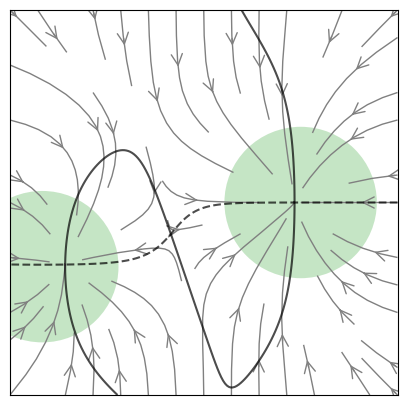

In [3]:

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

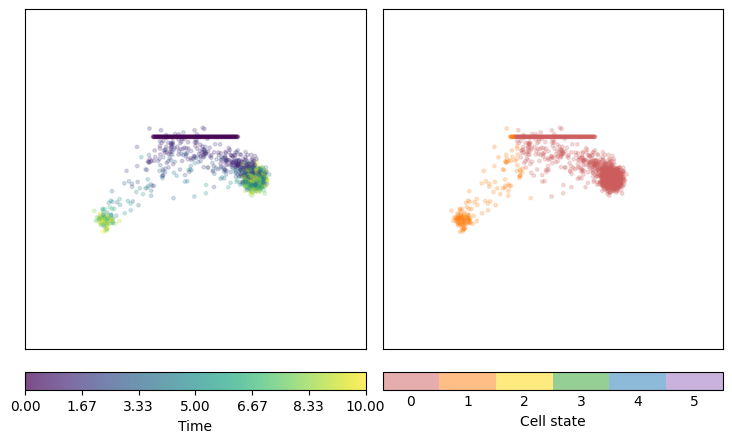

In [4]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
plt.show()

In [5]:
np.mean(states[:, :, -1], axis=1)

Array([0.91478115, 0.08521888], dtype=float32)

Train step 0 : Loss = 0.18731340765953064
Train step 5 : Loss = 0.058331072330474854
Train step 10 : Loss = 0.0028285831212997437
Train step 15 : Loss = 0.00023545324802398682
Train step 20 : Loss = 0.0076435282826423645
Train step 25 : Loss = 0.21216298639774323
Train step 30 : Loss = 0.0314452201128006
Train step 35 : Loss = 1.9736714363098145
Train step 40 : Loss = 2.204698085784912
Train step 45 : Loss = 1.5790497064590454
Train step 50 : Loss = 0.7724513411521912
Train step 55 : Loss = 0.24527201056480408
Train step 60 : Loss = 0.10383202135562897
Train step 65 : Loss = 0.09820516407489777
Train step 70 : Loss = 0.10304215550422668
Train step 75 : Loss = 0.11262601613998413
Train step 80 : Loss = 0.10761409997940063
Train step 85 : Loss = 0.0974835455417633
Train step 90 : Loss = 0.09090995788574219
Train step 95 : Loss = 0.08837911486625671
Landscape with modules:
Node: x=0.8697951436042786; y=-0.30110907554626465; a=[1.120929]; s=[0.31249753],
Node: x=1.1090131998062134; y=-0.32

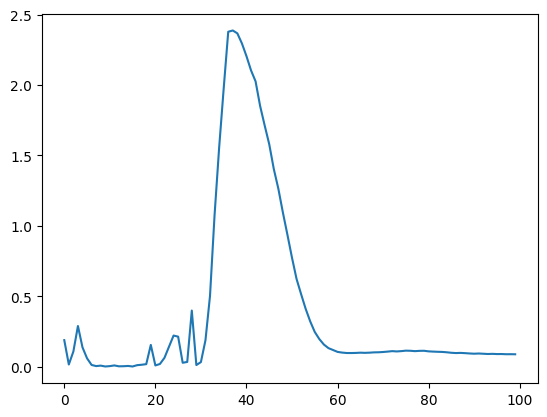

In [6]:
from evoscape.jax.losses import biseparating_fitness

def user_fitness(traj, states, dynamic, fitness_params):
    final_states = jnp.mean(states[:, :, -1], axis=1) # avg over cells

    # using target proportion 75% / 25%
    proportion_loss = jnp.sum((final_states - jnp.array((0.75, 0.25))) ** 2)

    return proportion_loss

opt = optax.adam(0.1)

losses = experiment.optimize(biseparating_fitness, fitness_params=(1., 0., [0.7, 0.3]), steps=100, optimizer=opt, seed=0)
optimized_landscape = experiment.get_landscape()

plt.plot(losses)
print(optimized_landscape)

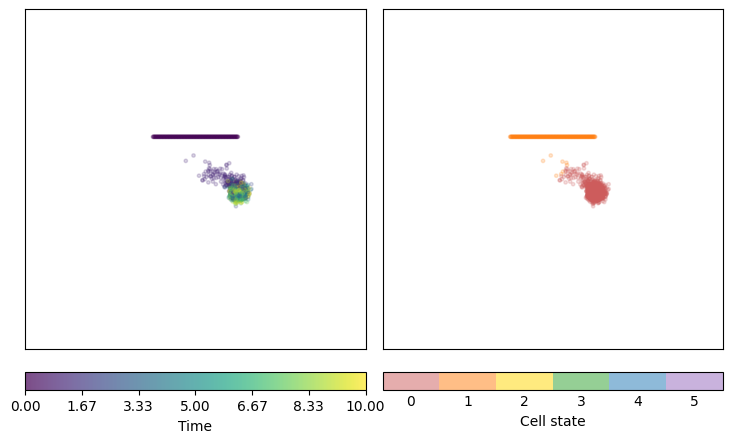

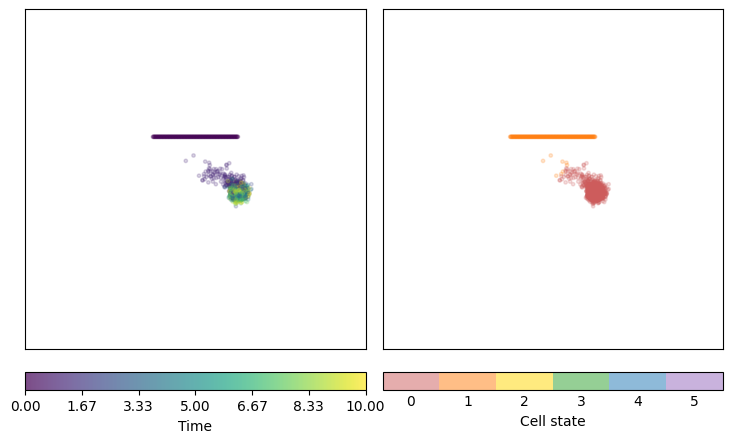

In [7]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
fig

In [8]:
np.mean(states[:, :, -1], axis=1)

Array([0.93943423, 0.06056575], dtype=float32)

Landscape with modules:
Node: x=0.8697951436042786; y=-0.30110907554626465; a=[1.120929]; s=[0.31249753],
Node: x=1.1090131998062134; y=-0.32655492424964905; a=[1.8225805]; s=[1.3512386]


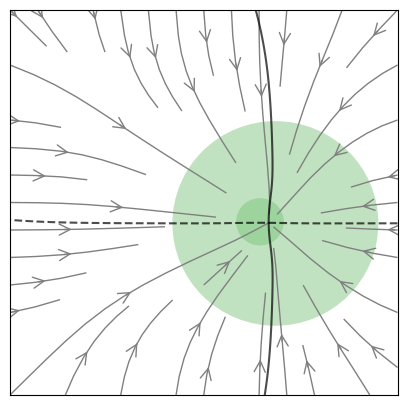

In [9]:
l = experiment.get_landscape()


print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')